Task 2: Quantitative analysis using pynance and TaLib

Prepare my Data

In [1]:
import pandas as pd

df = pd.read_csv("../data/AAPL.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.info()
df.isnull().sum()
df = df.dropna()

<class 'pandas.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


Compute SMA

In [3]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

df['SMA_50'] = df['Close'].rolling(window=50).mean()

Compute EMA

In [ ]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

Compute RSI

In [4]:
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()

Compute MACD

In [5]:
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()

df['MACD_signal'] = macd.macd_signal()

Price + Moving Average Plot

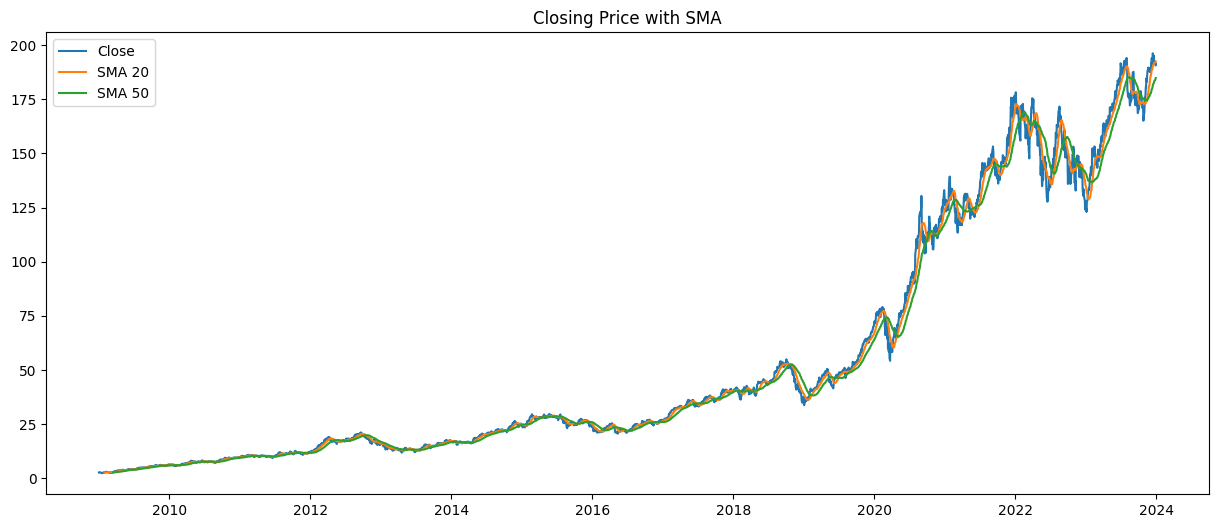

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close')

plt.plot(df['SMA_20'], label='SMA 20')

plt.plot(df['SMA_50'], label='SMA 50')

plt.legend()

plt.title("Closing Price with SMA")

plt.show()

RSI Plot

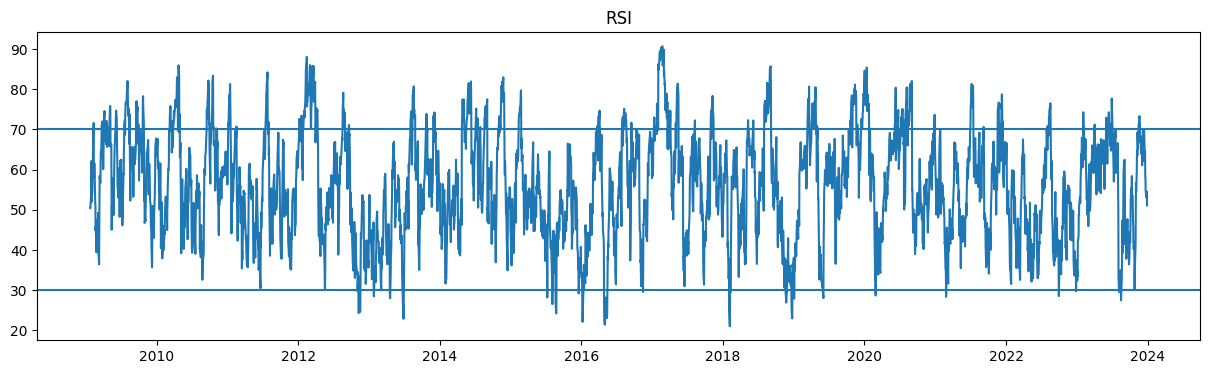

In [7]:
plt.figure(figsize=(15,4))

plt.plot(df['RSI'])

plt.axhline(70)

plt.axhline(30)

plt.title("RSI")

plt.show()

RSI > 70 → stoke overbought
RSI < 30 → stoke oversold

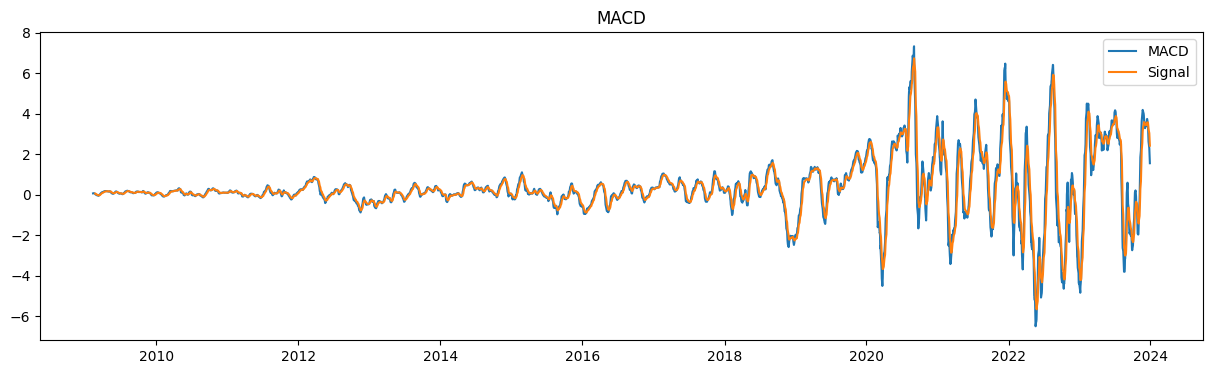

In [8]:
plt.figure(figsize=(15,4))

plt.plot(df['MACD'], label='MACD')

plt.plot(df['MACD_signal'], label='Signal')

plt.legend()

plt.title("MACD")

plt.show()

In [10]:

df['daily_return'] = df['Close'].pct_change()
df['daily_return'].describe()

count    3773.000000
mean        0.001289
std         0.018010
min        -0.128647
25%        -0.007547
50%         0.001062
75%         0.010770
max         0.119808
Name: daily_return, dtype: float64